# Reading the fit data

In [1]:
import csv
import numpy as np
import os
import pandas as pd

current_runs_title = "15.09.25"
steps_to_process = range(1,7)
js_fits_stepwise = []



for stepNo in steps_to_process:
    step_idx = stepNo - 1
    filename = f'JS_fits_Step{stepNo}.csv'
    full_preprocessed_data_folder_path = os.path.join("data\\preprocessed\\" + current_runs_title)
    
    file_path = os.path.join(full_preprocessed_data_folder_path, filename)
    df = pd.read_csv(file_path)
    js_fits_stepwise.append(df)



# Open the CSV file
# with open(filepath, 'r', newline='') as csvfile:
#     # Create a reader object
#     # csv.reader treats each row as a list of strings
#     csv_reader = csv.reader(csvfile)

#     # If the first row is a header, you can skip it
#     header = next(csv_reader)
#     print(f"Header: {header}")

    # # Iterate over each row in the CSV file
    # for row in csv_reader:
    #     print(row)

# Detecting Active Parameters By Model

In [2]:


def analyze_model_parameters(df, stepNo, param_columns=None):
    """
    Comprehensive analysis of active parameters and their characteristics
    """
    if param_columns is None:
        param_columns = ['epsM', 'epsSD', 'OpM', 'OpSD', 'MedM', 'MedSD', 
                        'MedInfF', 'Silence_Alpha', 'Silence_Tau', 
                        'Silence_Delta0', 'SilenceByBoundary']
    
    print(f"\n{'='*60}")
    print(f"MODEL {stepNo} ANALYSIS")
    print(f"{'='*60}")
    
    # Basic dataset info
    total_rows = len(df)
    unique_sim_indices = df['cumulative_simulation_index'].nunique()
    print(f"Total rows: {total_rows:,}")
    print(f"Unique simulation indices: {unique_sim_indices:,}")
    
    # Analyze RandomSeed structure
    random_seed_analysis = df.groupby('cumulative_simulation_index')['RandomSeed'].nunique()
    print(f"\nRANDOM SEED ANALYSIS:")
    print(f"Unique RandomSeed values: {df['RandomSeed'].nunique()}")
    print(f"RandomSeeds per simulation index:")
    print(f"  Min: {random_seed_analysis.min()}")
    print(f"  Max: {random_seed_analysis.max()}")
    print(f"  Mean: {random_seed_analysis.mean():.2f}")
    print(f"  Most common: {random_seed_analysis.mode().values[0]}")
    
    # Analyze active parameters
    active_params = []
    param_details = {}
    
    print(f"\nPARAMETER ANALYSIS:")
    for param in param_columns:
        unique_vals = df[param].nunique()
        val_range = (df[param].min(), df[param].max()) if unique_vals > 0 else (None, None)
        
        param_details[param] = {
            'unique_count': unique_vals,
            'range': val_range,
            'values': sorted(df[param].unique()) if unique_vals <= 10 else f"{unique_vals} values"
        }
        
        if unique_vals > 1:
            active_params.append(param)
            status = "ACTIVE"
        else:
            status = "CONSTANT"
        
        print(f"  {param:20} {status:10} Unique: {unique_vals:3} Range: {val_range}")
    
    # Analyze parameter combinations
    print(f"\nPARAMETER COMBINATIONS:")
    unique_param_combos = df[active_params].drop_duplicates()
    total_param_combos = len(unique_param_combos)
    print(f"Total unique parameter combinations: {total_param_combos:,}")
    
    # Check if RandomSeed creates additional dimension
    seeds_per_combo = df.groupby(active_params)['RandomSeed'].nunique()
    print(f"RandomSeeds per parameter combination:")
    print(f"  Min: {seeds_per_combo.min()}")
    print(f"  Max: {seeds_per_combo.max()}")
    print(f"  Mean: {seeds_per_combo.mean():.2f}")
    
    # Survey coverage analysis
    print(f"\nSURVEY COVERAGE:")
    unique_countries = df['country'].nunique()
    unique_years = df['year'].nunique()
    print(f"Countries: {unique_countries}")
    print(f"Years: {unique_years}")
    print(f"Total country-year surveys: {df[['country', 'year']].drop_duplicates().shape[0]}")
    
    # Return structured results
    results = {
        'stepNo': stepNo,
        'total_rows': total_rows,
        'unique_sim_indices': unique_sim_indices,
        'active_params': active_params,
        'param_details': param_details,
        'total_param_combos': total_param_combos,
        'random_seed_stats': {
            'unique_seeds': df['RandomSeed'].nunique(),
            'seeds_per_combo_min': seeds_per_combo.min(),
            'seeds_per_combo_max': seeds_per_combo.max(),
            'seeds_per_combo_mean': seeds_per_combo.mean()
        },
        'survey_coverage': {
            'countries': unique_countries,
            'years': unique_years,
            'total_surveys': df[['country', 'year']].drop_duplicates().shape[0]
        }
    }
    
    return results

# Main analysis loop
def comprehensive_analysis(steps_to_process, js_fits_stepwise):
    """
    Run comprehensive parameter analysis for all models
    """
    all_results = {}
    
    for stepNo in steps_to_process:
        step_idx = stepNo - 1
        df = js_fits_stepwise[step_idx]
        
        print(f"\n{'#'*80}")
        print(f"PROCESSING MODEL {stepNo}")
        print(f"{'#'*80}")
        
        results = analyze_model_parameters(df, stepNo)
        all_results[stepNo] = results
        
        # Quick JSD distribution summary
        print(f"\nJSD DISTRIBUTION (distance_final):")
        jsd_stats = df['distance_final'].describe()
        print(f"  Min:    {jsd_stats['min']:.4f}")
        print(f"  Mean:   {jsd_stats['mean']:.4f}")
        print(f"  Median: {jsd_stats['50%']:.4f}")
        print(f"  Max:    {jsd_stats['max']:.4f}")
        print(f"  Std:    {jsd_stats['std']:.4f}")
        
        # Count good fits (JSD < 0.05)
        good_fits = (df['distance_final'] < 0.05).sum()
        good_fit_pct = (good_fits / len(df)) * 100
        print(f"  Good fits (JSD < 0.05): {good_fits:,} ({good_fit_pct:.2f}%)")
    
    return all_results

# Usage example:
steps_to_process = [1, 2, 3, 4, 5, 6]  # Adjust based on what you want to process
all_results = comprehensive_analysis(steps_to_process, js_fits_stepwise)

# Create a summary table across all models
def create_summary_table(all_results):
    """Create a compact summary table for easy comparison"""
    summary_data = []
    
    for stepNo, results in all_results.items():
        summary_data.append({
            'Model': stepNo,
            'Total Rows': f"{results['total_rows']:,}",
            'Param Combinations': f"{results['total_param_combos']:,}",
            'Active Parameters': len(results['active_params']),
            'Random Seeds': results['random_seed_stats']['unique_seeds'],
            'Seeds/Combo': f"{results['random_seed_stats']['seeds_per_combo_mean']:.1f}",
            'Countries': results['survey_coverage']['countries'],
            'Years': results['survey_coverage']['years'],
            'Total Surveys': results['survey_coverage']['total_surveys']
        })
    
    return pd.DataFrame(summary_data)

# Display summary table
summary_df = create_summary_table(all_results)
print(f"\n{'#'*80}")
print("SUMMARY ACROSS ALL MODELS")
print(f"{'#'*80}")
print(summary_df.to_string(index=False))

# Also print active parameters for each model
print(f"\n{'#'*80}")
print("ACTIVE PARAMETERS BY MODEL")
print(f"{'#'*80}")
for stepNo, results in all_results.items():
    print(f"Model {stepNo}: {results['active_params']}")


################################################################################
PROCESSING MODEL 1
################################################################################

MODEL 1 ANALYSIS
Total rows: 984,900
Unique simulation indices: 2,100

RANDOM SEED ANALYSIS:
Unique RandomSeed values: 30
RandomSeeds per simulation index:
  Min: 1
  Max: 1
  Mean: 1.00
  Most common: 1

PARAMETER ANALYSIS:
  epsM                 ACTIVE     Unique:  70 Range: (0.01, 0.7)
  epsSD                CONSTANT   Unique:   1 Range: (0.0, 0.0)
  OpM                  CONSTANT   Unique:   1 Range: (0.0, 0.0)
  OpSD                 CONSTANT   Unique:   1 Range: (0.49, 0.49)
  MedM                 CONSTANT   Unique:   1 Range: (0.0, 0.0)
  MedSD                CONSTANT   Unique:   1 Range: (0.79, 0.79)
  MedInfF              CONSTANT   Unique:   1 Range: (0.91, 0.91)
  Silence_Alpha        CONSTANT   Unique:   0 Range: (None, None)
  Silence_Tau          CONSTANT   Unique:   0 Range: (None, None)
  Sil

In [3]:
active_params_stepwise = []
unique_param_combos_stepwise = []
param_summary_stepwise = []


# For each model, create a summary dataframe: one row per parameter combination
def create_param_summary(df, active_params):
    # Group by parameter combination, aggregate JSD values across all surveys
    summary = df.groupby(active_params + ['RandomSeed']).agg({
        'distance_final': ['mean', 'min', 'std'],
        'country': 'count'  # number of surveys this param combo was tested against
    }).reset_index()
    
    # Flatten column names
    summary.columns = ['_'.join(col).strip('_') for col in summary.columns]
    return summary


for stepNo in steps_to_process:
    step_idx = stepNo - 1
    df = js_fits_stepwise[step_idx].copy()
    
    # Identify active parameters for this model
    active_params = []
    param_columns = ['epsM', 'epsSD', 'OpM', 'OpSD', 'MedM', 'MedSD', 
                    'MedInfF', 'Silence_Alpha', 'Silence_Tau', 
                    'Silence_Delta0', 'SilenceByBoundary']
    
    for param in param_columns:
        if df[param].nunique() > 1:
            active_params.append(param)
    active_params_stepwise.append(active_params)
    print(f"Model {stepNo}: Active params: {active_params}")
    
    # Identify unique parameter combinations (ignoring RandomSeed)
    unique_param_combos = df[active_params].drop_duplicates()
    print(f"Model {stepNo}: {len(unique_param_combos)} unique parameter combinations")
    unique_param_combos_stepwise.append(unique_param_combos)
    
    # Usage in your loop:
    param_summary = create_param_summary(df, active_params)
    param_summary_stepwise.append(param_summary)
    


Model 1: Active params: ['epsM']
Model 1: 70 unique parameter combinations
Model 2: Active params: ['epsM']
Model 2: 70 unique parameter combinations
Model 3: Active params: ['epsM', 'epsSD']
Model 3: 100 unique parameter combinations
Model 4: Active params: ['epsM', 'epsSD', 'OpSD']
Model 4: 432 unique parameter combinations
Model 5: Active params: ['epsM', 'epsSD', 'MedM', 'MedSD', 'MedInfF']
Model 5: 7200 unique parameter combinations
Model 6: Active params: ['epsM', 'epsSD', 'MedM', 'MedSD', 'MedInfF', 'Silence_Alpha', 'Silence_Tau', 'Silence_Delta0', 'SilenceByBoundary']
Model 6: 62208 unique parameter combinations


# Testing Cross-seed Consistency

In [11]:

def efficient_cross_seed_consistency(df, active_params, sample_frac=0.01):
    """
    Efficiently compute cross-seed consistency by sampling
    """
    # For large models, sample parameter combinations first
    if len(df) > 1000000:  # If over 1M rows, sample
        param_sample = df[active_params].drop_duplicates().sample(frac=sample_frac)
        df_sampled = df.merge(param_sample, on=active_params)
        print(f"  Sampled {len(param_sample)} parameter combinations for consistency check")
    else:
        df_sampled = df
    
    # Group by parameters and compute consistency metric
    consistency_stats = df_sampled.groupby(active_params).agg({
        'distance_final': ['std', 'mean', 'count']
    }).reset_index()
    
    # Flatten columns
    consistency_stats.columns = ['_'.join(col).strip('_') for col in consistency_stats.columns]
    
    # Calculate coefficient of variation (std/mean) - lower = more consistent
    consistency_stats['coeff_variation'] = consistency_stats['distance_final_std'] / consistency_stats['distance_final_mean']
    
    return {
        'mean_std': consistency_stats['distance_final_std'].mean(),
        'mean_coeff_variation': consistency_stats['coeff_variation'].mean(),
        'consistent_fraction': (consistency_stats['coeff_variation'] < 0.1).mean()  # <10% variation
    }

# Add to your main loop
consistency_results = []
for stepNo in steps_to_process:
    step_idx = stepNo - 1
    df = js_fits_stepwise[step_idx].copy()
    active_params = active_params_stepwise[step_idx]
    
    print(f"Model {stepNo}: Computing cross-seed consistency...")
    consistency = efficient_cross_seed_consistency(df, active_params)
    consistency_results.append(consistency)
    print(f"  Mean coefficient of variation: {consistency['mean_coeff_variation']:.3f}")
    print(f"  Consistent fraction: {consistency['consistent_fraction']:.3f}")

Model 1: Computing cross-seed consistency...
  Mean coefficient of variation: 0.103
  Consistent fraction: 0.814
Model 2: Computing cross-seed consistency...
  Mean coefficient of variation: 0.157
  Consistent fraction: 0.286
Model 3: Computing cross-seed consistency...
  Sampled 1 parameter combinations for consistency check
  Mean coefficient of variation: 0.209
  Consistent fraction: 0.000
Model 4: Computing cross-seed consistency...
  Sampled 4 parameter combinations for consistency check
  Mean coefficient of variation: 0.135
  Consistent fraction: 0.750
Model 5: Computing cross-seed consistency...
  Sampled 72 parameter combinations for consistency check
  Mean coefficient of variation: 0.146
  Consistent fraction: 0.167
Model 6: Computing cross-seed consistency...
  Sampled 622 parameter combinations for consistency check
  Mean coefficient of variation: 0.156
  Consistent fraction: 0.170


# DeepSeek's interpretation


In [19]:
def interpret_consistency(consistency_results):
    print("CROSS-SEED CONSISTENCY INTERPRETATION:")
    print("="*50)
    print("Coefficient of Variation (CV) = Standard Deviation / Mean")
    print("Lower CV = More consistent across random seeds")
    print("Consistent Fraction = % of param combos with CV < 0.1")
    print("\nKEY INSIGHTS:")
    
    for i, consistency in enumerate(consistency_results, 1):
        print(f"\nModel {i}:")
        print(f"  CV: {consistency['mean_coeff_variation']:.3f} | Consistent: {consistency['consistent_fraction']:.1%}")
        
        if consistency['mean_coeff_variation'] < 0.1:
            print("  → HIGH consistency: Results are robust to random initialization")
        elif consistency['mean_coeff_variation'] < 0.2:
            print("  → MODERATE consistency: Some seed dependence")
        else:
            print("  → LOW consistency: Highly dependent on random seed")
    

interpret_consistency(consistency_results)

CROSS-SEED CONSISTENCY INTERPRETATION:
Coefficient of Variation (CV) = Standard Deviation / Mean
Lower CV = More consistent across random seeds
Consistent Fraction = % of param combos with CV < 0.1

KEY INSIGHTS:

Model 1:
  CV: 0.103 | Consistent: 81.4%
  → MODERATE consistency: Some seed dependence

Model 2:
  CV: 0.157 | Consistent: 28.6%
  → MODERATE consistency: Some seed dependence

Model 3:
  CV: 0.209 | Consistent: 0.0%
  → LOW consistency: Highly dependent on random seed

Model 4:
  CV: 0.135 | Consistent: 75.0%
  → MODERATE consistency: Some seed dependence

Model 5:
  CV: 0.146 | Consistent: 16.7%
  → MODERATE consistency: Some seed dependence

Model 6:
  CV: 0.156 | Consistent: 17.0%
  → MODERATE consistency: Some seed dependence

TREND: Consistency generally DECREASES with model complexity
This suggests simpler models are more deterministic, while
complex models have more chaotic/seed-dependent behavior


# Overlap Test for "Good Regions" in the Parameter space

We will aim to test if our 'good regions' in the parameter spaces -- i.e. the ones that give good fits -- are a robust finding. 

We do this by testing for correlation in param spaces across different splits of the data.
We adopt two strategies:
1. Splitting across countries
2. Splitting across random seeds

In [24]:
def create_binary_success_metric(df, active_params, top_percentile=5):
    """
    Create binary success metric: 1 if in top 5% of fits, 0 otherwise
    """
    # Calculate fitness as minimum JSD across random seeds for each parameter combination
    fitness = df.groupby(active_params)['distance_final'].min().reset_index()
    fitness.columns = active_params + ['min_jsd']
    
    # Find threshold for top 5%
    threshold = fitness['min_jsd'].quantile(top_percentile / 100)
    
    # Mark successful parameter combinations
    fitness['success'] = (fitness['min_jsd'] <= threshold).astype(int)
    
    return fitness[active_params + ['success', 'min_jsd']]

def calculate_overlap_metrics(train_success, test_success, all_param_combos):
    """
    Calculate overlap metrics between training and test successful parameters
    """
    train_good = set([tuple(x) for x in train_success[train_success['success'] == 1][active_params].values])
    test_good = set([tuple(x) for x in test_success[test_success['success'] == 1][active_params].values])
    
    if len(all_param_combos) == 0:
        return {}
    
    overlap_metrics = {
        'total_param_space_size': len(all_param_combos),
        'train_good_size': len(train_good),
        'test_good_size': len(test_good),
        'overlap_size': len(train_good & test_good),
        'overlap_fraction_of_train': len(train_good & test_good) / len(train_good) if train_good else 0,
        'overlap_fraction_of_test': len(train_good & test_good) / len(test_good) if test_good else 0,
        'overlap_fraction_of_total': len(train_good & test_good) / len(all_param_combos),
        'train_success_rate': len(train_good) / len(all_param_combos),
        'test_success_rate': len(test_good) / len(all_param_combos)
    }
    
    return overlap_metrics

def run_country_split_overlap(df, active_params, n_splits=5, top_percentile=5):
    """
    Run country-based cross-validation overlap analysis
    """
    countries = df['country'].unique()
    overlap_results = []
    
    for split_idx in range(n_splits):
        # Random 50-50 country split
        np.random.shuffle(countries)
        split_point = len(countries) // 2
        train_countries = countries[:split_point]
        test_countries = countries[split_point:]
        
        # Split data
        train_data = df[df['country'].isin(train_countries)]
        test_data = df[df['country'].isin(test_countries)]
        
        # Get successful parameter combinations
        train_success = create_binary_success_metric(train_data, active_params, top_percentile)
        test_success = create_binary_success_metric(test_data, active_params, top_percentile)
        
        # All possible parameter combinations
        all_param_combos = set([tuple(x) for x in df[active_params].drop_duplicates().values])
        
        # Calculate overlap
        overlap_metrics = calculate_overlap_metrics(train_success, test_success, all_param_combos)
        overlap_metrics['split_idx'] = split_idx
        overlap_metrics['split_type'] = 'country'
        overlap_metrics['train_countries'] = len(train_countries)
        overlap_metrics['test_countries'] = len(test_countries)
        
        overlap_results.append(overlap_metrics)
    
    return overlap_results

def run_seed_split_overlap(df, active_params, n_splits=5, top_percentile=5):
    """
    Run random seed-based cross-validation overlap analysis
    """
    all_seeds = df['RandomSeed'].unique()
    overlap_results = []
    
    for split_idx in range(n_splits):
        # Random 50-50 seed split
        np.random.shuffle(all_seeds)
        split_point = len(all_seeds) // 2
        train_seeds = all_seeds[:split_point]
        test_seeds = all_seeds[split_point:]
        
        # Split data
        train_data = df[df['RandomSeed'].isin(train_seeds)]
        test_data = df[df['RandomSeed'].isin(test_seeds)]
        
        # Get successful parameter combinations
        train_success = create_binary_success_metric(train_data, active_params, top_percentile)
        test_success = create_binary_success_metric(test_data, active_params, top_percentile)
        
        # All possible parameter combinations
        all_param_combos = set([tuple(x) for x in df[active_params].drop_duplicates().values])
        
        # Calculate overlap
        overlap_metrics = calculate_overlap_metrics(train_success, test_success, all_param_combos)
        overlap_metrics['split_idx'] = split_idx
        overlap_metrics['split_type'] = 'seed'
        overlap_metrics['train_seeds'] = len(train_seeds)
        overlap_metrics['test_seeds'] = len(test_seeds)
        
        overlap_results.append(overlap_metrics)
    
    return overlap_results

In [41]:
def create_binary_success_metric_v2(df, active_params, top_percentile=5):
    """
    Improved version that tracks absolute counts
    """
    # Calculate fitness as minimum JSD across random seeds for each parameter combination
    fitness = df.groupby(active_params)['distance_final'].min().reset_index()
    fitness.columns = active_params + ['min_jsd']
    
    # Find threshold for top 5%
    threshold = fitness['min_jsd'].quantile(top_percentile / 100)
    
    # Mark successful parameter combinations
    fitness['success'] = (fitness['min_jsd'] <= threshold).astype(int)
    
    # Add absolute counts
    total_combos = len(fitness)
    good_combos = fitness['success'].sum()
    
    return fitness, total_combos, good_combos, threshold

def calculate_overlap_metrics_v2(train_success, test_success, all_param_combos):
    """
    Improved overlap metrics with absolute numbers
    """
    train_good = set([tuple(x) for x in train_success[train_success['success'] == 1][active_params].values])
    test_good = set([tuple(x) for x in test_success[test_success['success'] == 1][active_params].values])
    
    if len(all_param_combos) == 0:
        return {}
    
    total_space_size = len(all_param_combos)
    overlap_size = len(train_good & test_good)
    
    overlap_metrics = {
        'total_param_space_size': total_space_size,
        'train_good_size': len(train_good),
        'test_good_size': len(test_good),
        'overlap_size': overlap_size,
        'overlap_fraction_of_train': overlap_size / len(train_good) if train_good else 0,
        'overlap_fraction_of_test': overlap_size / len(test_good) if test_good else 0,
        'overlap_fraction_of_total': overlap_size / total_space_size,
        'train_success_rate': len(train_good) / total_space_size,
        'test_success_rate': len(test_good) / total_space_size,
        'train_good_abs': len(train_good),
        'test_good_abs': len(test_good),
        'overlap_abs': overlap_size
    }
    
    return overlap_metrics

def run_country_split_overlap_v2(df, active_params, n_splits=5, top_percentile=5):
    """
    Improved version with better reporting
    """
    countries = df['country'].unique()
    overlap_results = []
    
    for split_idx in range(n_splits):
        # Random 50-50 country split
        np.random.shuffle(countries)
        split_point = len(countries) // 2
        train_countries = countries[:split_point]
        test_countries = countries[split_point:]
        
        # Split data
        train_data = df[df['country'].isin(train_countries)]
        test_data = df[df['country'].isin(test_countries)]
        
        # Get successful parameter combinations
        train_success, train_total, train_good, train_threshold = create_binary_success_metric_v2(train_data, active_params, top_percentile)
        test_success, test_total, test_good, test_threshold = create_binary_success_metric_v2(test_data, active_params, top_percentile)
        
        # All possible parameter combinations
        all_param_combos = set([tuple(x) for x in df[active_params].drop_duplicates().values])
        
        # Calculate overlap
        overlap_metrics = calculate_overlap_metrics_v2(train_success, test_success, all_param_combos)
        overlap_metrics['split_idx'] = split_idx
        overlap_metrics['split_type'] = 'country'
        overlap_metrics['train_countries'] = len(train_countries)
        overlap_metrics['test_countries'] = len(test_countries)
        overlap_metrics['train_threshold'] = train_threshold
        overlap_metrics['test_threshold'] = test_threshold
        
        overlap_results.append(overlap_metrics)
    
    return overlap_results

In [45]:
# Store all results
overlap_results_stepwise = []

for stepNo in steps_to_process:
    step_idx = stepNo - 1
    df = js_fits_stepwise[step_idx].copy()
    active_params = active_params_stepwise[step_idx]
    
    print(f"\n{'='*60}")
    print(f"MODEL {stepNo} OVERLAP ANALYSIS")
    print(f"{'='*60}")
    
    model_results = {
        'stepNo': stepNo,
        'country_splits': [],
        'seed_splits': []
    }
    
    # Run country-based splits
    print("Running country splits...")
    country_results = run_country_split_overlap_v2(df, active_params, n_splits=5, top_percentile=5)
    model_results['country_splits'] = country_results
    
    # Run seed-based splits (only if multiple seeds exist)
    if df['RandomSeed'].nunique() > 1:
        print("Running seed splits...")
        seed_results = run_seed_split_overlap(df, active_params, n_splits=5, top_percentile=5)
        model_results['seed_splits'] = seed_results
    else:
        print("Skipping seed splits (only one RandomSeed)")
        model_results['seed_splits'] = []
    
    overlap_results_stepwise.append(model_results)
    
    # Print summary for this model
    print(f"\nModel {stepNo} Summary:")
    if country_results:
        country_overlaps = [r['overlap_fraction_of_train'] for r in country_results]
        print(f"  Country splits - Mean overlap: {np.mean(country_overlaps):.3f} ± {np.std(country_overlaps):.3f}")
    
    if model_results['seed_splits']:
        seed_overlaps = [r['overlap_fraction_of_train'] for r in model_results['seed_splits']]
        print(f"  Seed splits - Mean overlap: {np.mean(seed_overlaps):.3f} ± {np.std(seed_overlaps):.3f}")


MODEL 1 OVERLAP ANALYSIS
Running country splits...
Running seed splits...

Model 1 Summary:
  Country splits - Mean overlap: 1.000 ± 0.000
  Seed splits - Mean overlap: 1.000 ± 0.000

MODEL 2 OVERLAP ANALYSIS
Running country splits...
Running seed splits...

Model 2 Summary:
  Country splits - Mean overlap: 0.050 ± 0.100
  Seed splits - Mean overlap: 0.150 ± 0.122

MODEL 3 OVERLAP ANALYSIS
Running country splits...
Running seed splits...

Model 3 Summary:
  Country splits - Mean overlap: 0.360 ± 0.080
  Seed splits - Mean overlap: 0.160 ± 0.080

MODEL 4 OVERLAP ANALYSIS
Running country splits...
Running seed splits...

Model 4 Summary:
  Country splits - Mean overlap: 0.445 ± 0.159
  Seed splits - Mean overlap: 0.400 ± 0.034

MODEL 5 OVERLAP ANALYSIS
Running country splits...
Running seed splits...

Model 5 Summary:
  Country splits - Mean overlap: 0.549 ± 0.057
  Seed splits - Mean overlap: 0.719 ± 0.012

MODEL 6 OVERLAP ANALYSIS
Running country splits...
Running seed splits...

Mode

In [26]:
def create_overlap_summary_table(overlap_results_stepwise):
    """Create summary table across all models and split types"""
    summary_data = []
    
    for model_results in overlap_results_stepwise:
        stepNo = model_results['stepNo']
        
        # Country splits summary
        if model_results['country_splits']:
            country_overlaps = [r['overlap_fraction_of_train'] for r in model_results['country_splits']]
            summary_data.append({
                'Model': stepNo,
                'Split Type': 'Country',
                'Mean Overlap': np.mean(country_overlaps),
                'Std Overlap': np.std(country_overlaps),
                'Mean Train Success Rate': np.mean([r['train_success_rate'] for r in model_results['country_splits']]),
                'Mean Test Success Rate': np.mean([r['test_success_rate'] for r in model_results['country_splits']])
            })
        
        # Seed splits summary  
        if model_results['seed_splits']:
            seed_overlaps = [r['overlap_fraction_of_train'] for r in model_results['seed_splits']]
            summary_data.append({
                'Model': stepNo,
                'Split Type': 'Seed',
                'Mean Overlap': np.mean(seed_overlaps),
                'Std Overlap': np.std(seed_overlaps),
                'Mean Train Success Rate': np.mean([r['train_success_rate'] for r in model_results['seed_splits']]),
                'Mean Test Success Rate': np.mean([r['test_success_rate'] for r in model_results['seed_splits']])
            })
    
    return pd.DataFrame(summary_data)

# Create and display final summary
overlap_summary = create_overlap_summary_table(overlap_results_stepwise)
print(f"\n{'#'*80}")
print("FINAL OVERLAP ANALYSIS SUMMARY")
print(f"{'#'*80}")
print(overlap_summary.round(3).to_string(index=False))


################################################################################
FINAL OVERLAP ANALYSIS SUMMARY
################################################################################
 Model Split Type  Mean Overlap  Std Overlap  Mean Train Success Rate  Mean Test Success Rate
     1    Country         1.000        0.000                    0.057                   0.057
     1       Seed         1.000        0.000                    0.057                   0.057
     2    Country         0.050        0.100                    0.057                   0.057
     2       Seed         0.100        0.122                    0.057                   0.057
     3    Country         0.400        0.000                    0.050                   0.050
     3       Seed         0.160        0.080                    0.050                   0.050
     4    Country         0.491        0.093                    0.051                   0.051
     4       Seed         0.427        0.055          


################################################################################
ENHANCED SUMMARY WITH EXPECTED VALUES
################################################################################
 Model Split Type  Mean Overlap  Std Overlap  Expected Overlap  Effect Size  Mean Train Success Rate  Mean Test Success Rate Effect Strength
     1    Country         1.000        0.000               0.0          0.0                    0.057                   0.057          RANDOM
     1       Seed         1.000        0.000               0.0          0.0                    0.057                   0.057          RANDOM
     2    Country         0.050        0.100               0.0          0.0                    0.057                   0.057          RANDOM
     2       Seed         0.150        0.122               0.0          0.0                    0.057                   0.057          RANDOM
     3    Country         0.360        0.080               0.0          0.0                   

# Venn Diagrams for Overlap

Creating fixed country split Venn diagrams...


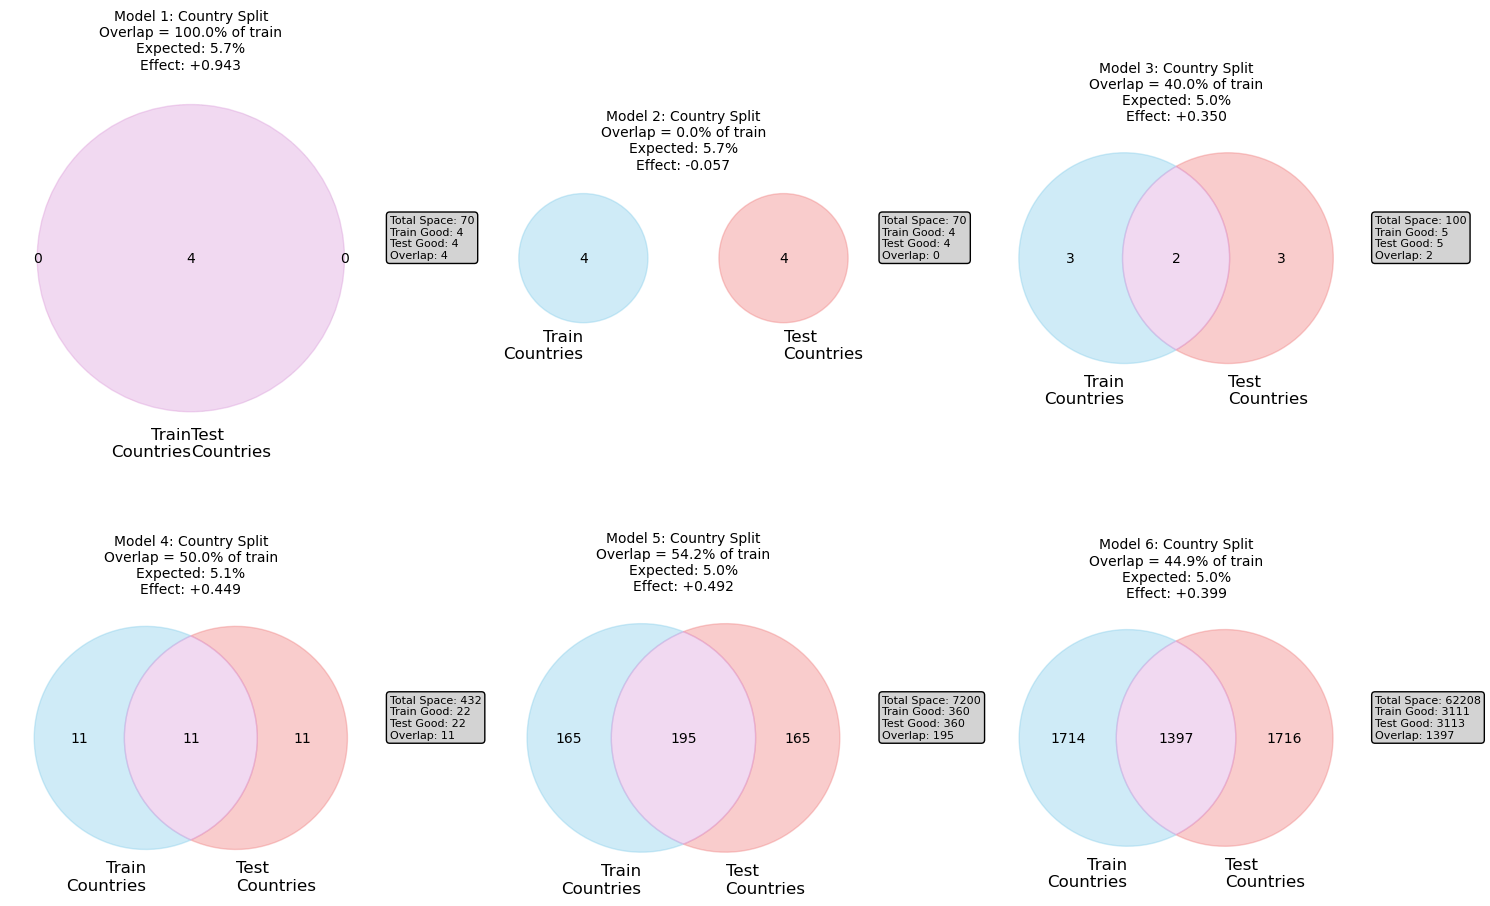

In [77]:
def create_country_venn_diagrams_fixed(overlap_results_stepwise, split_idx=0):
    """
    Fixed Venn diagrams that handle cases with no overlap
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for model_idx, model_results in enumerate(overlap_results_stepwise):
        if model_idx >= len(axes):
            break
            
        stepNo = model_results['stepNo']
        country_splits = model_results['country_splits']
        
        if not country_splits or split_idx >= len(country_splits):
            continue
            
        overlap_data = country_splits[split_idx]
        
        # Calculate set sizes from the available data
        total_space = overlap_data['total_param_space_size']
        train_success_rate = overlap_data['train_success_rate']
        test_success_rate = overlap_data['test_success_rate']
        overlap_frac = overlap_data['overlap_fraction_of_train']
        
        # Calculate absolute sizes
        train_good_abs = int(total_space * train_success_rate)
        test_good_abs = int(total_space * test_success_rate)
        overlap_abs = int(train_good_abs * overlap_frac)
        
        # Create Venn diagram
        ax = axes[model_idx]
        
        # Handle cases with no overlap
        if overlap_abs == 0:
            # Use venn2 with no overlap
            v = venn2(subsets=(train_good_abs, test_good_abs, 0),
                      set_labels=('Train\nCountries', 'Test\nCountries'),
                      ax=ax)
        else:
            v = venn2(subsets=(train_good_abs - overlap_abs, test_good_abs - overlap_abs, overlap_abs),
                      set_labels=('Train\nCountries', 'Test\nCountries'),
                      ax=ax)
        
        # Customize colors - only if the patches exist
        try:
            if train_good_abs - overlap_abs > 0:
                v.get_patch_by_id('10').set_color('skyblue')
            if test_good_abs - overlap_abs > 0:
                v.get_patch_by_id('01').set_color('lightcoral')
            if overlap_abs > 0:
                v.get_patch_by_id('11').set_color('plum')
        except AttributeError:
            print(f"Model {stepNo}: Some Venn diagram patches don't exist (no overlap)")
        
        # Add expected overlap if available
        expected_text = ""
        if 'expected_overlap_fraction_of_train' in overlap_data:
            expected_overlap = overlap_data['expected_overlap_fraction_of_train']
            effect_size = overlap_data.get('overlap_effect_size', 0)
            expected_text = f"\nExpected: {expected_overlap:.1%}\nEffect: {effect_size:+.3f}"
        
        ax.set_title(f'Model {stepNo}: Country Split\n'
                    f"Overlap = {overlap_frac:.1%} of train{expected_text}",
                    fontsize=10)
        
        # Add annotation with key metrics
        metrics_text = (f"Total Space: {total_space}\n"
                       f"Train Good: {train_good_abs}\n"
                       f"Test Good: {test_good_abs}\n"
                       f"Overlap: {overlap_abs}")
        
        ax.annotate(metrics_text, xy=(1.05, 0.5), xycoords='axes fraction',
                   fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
    
    # Remove empty subplots
    for i in range(len(overlap_results_stepwise), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Try the fixed version
try:
    print("Creating fixed country split Venn diagrams...")
    create_country_venn_diagrams_fixed(overlap_results_stepwise)
except Exception as e:
    print(f"Venn diagrams failed: {e}")
    print("Skipping Venn diagrams and moving to clustering analysis...")

In [59]:
# Debug: Check what keys exist in your results
print("Debug: Checking keys in first model's first country split...")
if overlap_results_stepwise and overlap_results_stepwise[0]['country_splits']:
    first_split = overlap_results_stepwise[0]['country_splits'][0]
    print("Available keys:", list(first_split.keys()))

Debug: Checking keys in first model's first country split...
Available keys: ['total_param_space_size', 'train_good_size', 'test_good_size', 'overlap_size', 'overlap_fraction_of_train', 'overlap_fraction_of_test', 'overlap_fraction_of_total', 'train_success_rate', 'test_success_rate', 'train_good_abs', 'test_good_abs', 'overlap_abs', 'split_idx', 'split_type', 'train_countries', 'test_countries', 'train_threshold', 'test_threshold', 'expected_expected_overlap_fraction_of_train', 'expected_expected_overlap_size', 'expected_expected_overlap_fraction_of_total']


# Scrambled Control/ Analytical chance comparison for Overlap Data

In [61]:
def add_expected_overlap_to_results(overlap_results_stepwise):
    """
    Add expected-by-chance overlap to all results
    """
    for model_idx, model_results in enumerate(overlap_results_stepwise):
        print(f"Processing Model {model_idx + 1}...")
        
        # For country splits
        for split_idx, split_result in enumerate(model_results['country_splits']):
            total_space = split_result['total_param_space_size']
            success_rate = split_result['train_success_rate']
            
            print(f"  Country split {split_idx}: total_space={total_space}, success_rate={success_rate}")
            
            expected = calculate_expected_overlap(total_space, success_rate)
            
            # Debug: print what we're adding
            print(f"    Adding expected values: {list(expected.keys())}")
            
            # Add expected values to the result
            for key, value in expected.items():
                new_key = f'expected_{key}'
                split_result[new_key] = value
                print(f"    Added {new_key} = {value}")
            
            # Now calculate effect size - the keys should exist now
            if 'expected_overlap_fraction_of_train' in split_result:
                split_result['overlap_effect_size'] = (
                    split_result['overlap_fraction_of_train'] - 
                    split_result['expected_overlap_fraction_of_train']
                )
                print(f"    Effect size: {split_result['overlap_effect_size']}")
            else:
                print("    ERROR: expected_overlap_fraction_of_train not found!")
        
        # For seed splits
        for split_idx, split_result in enumerate(model_results['seed_splits']):
            total_space = split_result['total_param_space_size']
            success_rate = split_result['train_success_rate']
            
            print(f"  Seed split {split_idx}: total_space={total_space}, success_rate={success_rate}")
            
            expected = calculate_expected_overlap(total_space, success_rate)
            
            # Add expected values to the result
            for key, value in expected.items():
                split_result[f'expected_{key}'] = value
            
            # Calculate effect size
            if 'expected_overlap_fraction_of_train' in split_result:
                split_result['overlap_effect_size'] = (
                    split_result['overlap_fraction_of_train'] - 
                    split_result['expected_overlap_fraction_of_train']
                )
    
    return overlap_results_stepwise

def add_expected_overlap_simple(overlap_results_stepwise):
    """
    Simple robust version to add expected overlap calculations
    """
    for model_results in overlap_results_stepwise:
        # Process country splits
        for split_result in model_results.get('country_splits', []):
            add_expected_to_single_split(split_result)
        
        # Process seed splits  
        for split_result in model_results.get('seed_splits', []):
            add_expected_to_single_split(split_result)
    
    return overlap_results_stepwise

def add_expected_to_single_split(split_result):
    """Add expected overlap to a single split result"""
    try:
        total_space = split_result['total_param_space_size']
        success_rate = split_result['train_success_rate']
        
        # Calculate expected values
        expected_overlap_prob = success_rate ** 2
        expected_overlap_fraction = expected_overlap_prob / success_rate if success_rate > 0 else 0
        expected_overlap_size = total_space * expected_overlap_prob
        
        # Store results
        split_result['expected_overlap_fraction_of_train'] = expected_overlap_fraction
        split_result['expected_overlap_size'] = expected_overlap_size
        split_result['expected_overlap_fraction_of_total'] = expected_overlap_prob
        
        # Calculate effect size
        split_result['overlap_effect_size'] = (
            split_result['overlap_fraction_of_train'] - expected_overlap_fraction
        )
        
    except KeyError as e:
        print(f"Warning: Missing key {e} in split result")
    except Exception as e:
        print(f"Error processing split: {e}")

# Use the simple version instead
print("Calculating expected overlap by chance...")
overlap_results_stepwise = add_expected_overlap_simple(overlap_results_stepwise)

Calculating expected overlap by chance...


In [67]:
overlap_results_stepwise [0]['country_splits'][0]

{'total_param_space_size': 70,
 'train_good_size': 4,
 'test_good_size': 4,
 'overlap_size': 4,
 'overlap_fraction_of_train': 1.0,
 'overlap_fraction_of_test': 1.0,
 'overlap_fraction_of_total': 0.05714285714285714,
 'train_success_rate': 0.05714285714285714,
 'test_success_rate': 0.05714285714285714,
 'train_good_abs': 4,
 'test_good_abs': 4,
 'overlap_abs': 4,
 'split_idx': 0,
 'split_type': 'country',
 'train_countries': 16,
 'test_countries': 16,
 'train_threshold': np.float64(0.1724503291646179),
 'test_threshold': np.float64(0.14197150897152042),
 'expected_expected_overlap_fraction_of_train': 0.05714285714285714,
 'expected_expected_overlap_size': 0.22857142857142854,
 'expected_expected_overlap_fraction_of_total': 0.0032653061224489793,
 'expected_overlap_fraction_of_train': 0.05714285714285714,
 'expected_overlap_size': 0.22857142857142854,
 'expected_overlap_fraction_of_total': 0.0032653061224489793,
 'overlap_effect_size': 0.9428571428571428}

In [68]:
def create_enhanced_summary_table(overlap_results_stepwise):
    """Create summary table with expected values and effect sizes"""
    summary_data = []
    
    for model_results in overlap_results_stepwise:
        stepNo = model_results['stepNo']
        
        # Country splits summary
        if model_results['country_splits']:
            country_overlaps = [r['overlap_fraction_of_train'] for r in model_results['country_splits']]
            country_expected = [r.get('expected_overlap_fraction_of_train', 0) for r in model_results['country_splits']]
            country_effects = [r.get('overlap_effect_size', 0) for r in model_results['country_splits']]
            
            summary_data.append({
                'Model': stepNo,
                'Split Type': 'Country',
                'Mean Overlap': np.mean(country_overlaps),
                'Std Overlap': np.std(country_overlaps),
                'Expected Overlap': np.mean(country_expected),
                'Effect Size': np.mean(country_effects),
                'Mean Train Success Rate': np.mean([r['train_success_rate'] for r in model_results['country_splits']]),
                'Mean Test Success Rate': np.mean([r['test_success_rate'] for r in model_results['country_splits']])
            })
        
        # Seed splits summary  
        if model_results['seed_splits']:
            seed_overlaps = [r['overlap_fraction_of_train'] for r in model_results['seed_splits']]
            seed_expected = [r.get('expected_overlap_fraction_of_train', 0) for r in model_results['seed_splits']]
            seed_effects = [r.get('overlap_effect_size', 0) for r in model_results['seed_splits']]
            
            summary_data.append({
                'Model': stepNo,
                'Split Type': 'Seed',
                'Mean Overlap': np.mean(seed_overlaps),
                'Std Overlap': np.std(seed_overlaps),
                'Expected Overlap': np.mean(seed_expected),
                'Effect Size': np.mean(seed_effects),
                'Mean Train Success Rate': np.mean([r['train_success_rate'] for r in model_results['seed_splits']]),
                'Mean Test Success Rate': np.mean([r['test_success_rate'] for r in model_results['seed_splits']])
            })
    
    df = pd.DataFrame(summary_data)
    
    # Add interpretation column
    def interpret_effect_size(row):
        effect = row['Effect Size']
        if effect > 0.3:
            return "STRONG"
        elif effect > 0.1:
            return "MODERATE" 
        elif effect > 0:
            return "WEAK"
        else:
            return "RANDOM"
    
    df['Effect Strength'] = df.apply(interpret_effect_size, axis=1)
    
    return df

# Create and display enhanced summary
enhanced_summary = create_enhanced_summary_table(overlap_results_stepwise)
print(f"\n{'#'*80}")
print("SUMMARY WITH EXPECTED VALUES")
print(f"{'#'*80}")
print(enhanced_summary.round(3).to_string(index=False))


################################################################################
ENHANCED SUMMARY WITH EXPECTED VALUES
################################################################################
 Model Split Type  Mean Overlap  Std Overlap  Expected Overlap  Effect Size  Mean Train Success Rate  Mean Test Success Rate Effect Strength
     1    Country         1.000        0.000             0.057        0.943                    0.057                   0.057          STRONG
     1       Seed         1.000        0.000             0.057        0.943                    0.057                   0.057          STRONG
     2    Country         0.050        0.100             0.057       -0.007                    0.057                   0.057          RANDOM
     2       Seed         0.150        0.122             0.057        0.093                    0.057                   0.057            WEAK
     3    Country         0.360        0.080             0.050        0.310                   

# Saving Overlap Data

In [76]:
import os

def save_summary_table(enhanced_summary, filepath=os.path.join("analysis\\" + current_runs_title)):
    """Save the enhanced summary table to CSV and Excel"""
    # Create directory if it doesn't exist
    os.makedirs(filepath, exist_ok=True)
    
    # Save as CSV
    csv_path = os.path.join(filepath, "enhanced_summary.csv")
    enhanced_summary.to_csv(csv_path, index=False)
    print(f"Summary table saved to: {csv_path}")
    
    # Also save as Excel if possible
    try:
        excel_path = os.path.join(filepath, "enhanced_summary.xlsx")
        enhanced_summary.to_excel(excel_path, index=False)
        print(f"Summary table saved to: {excel_path}")
    except ImportError:
        print("Excel export skipped (openpyxl not installed)")
    
    return csv_path

# Save your table
table_path = save_summary_table(enhanced_summary)


Summary table saved to: analysis\15.09.25\enhanced_summary.csv
Summary table saved to: analysis\15.09.25\enhanced_summary.xlsx


In [74]:
table_path

'data\\preprocessed\\15.09.25\\enhanced_summary.csv'

# Clustering in the 'Good Space'

In [80]:
import math
def efficient_clustering_analysis(df, active_params, sample_frac=0.1):
    """
    Efficient clustering analysis for large parameter spaces
    Returns clustering metrics that are comparable across models
    """
    # Step 1: Aggregate across random seeds - count successes per parameter combination
    param_success_counts = df.groupby(active_params).agg({
        'distance_final': lambda x: (x < x.quantile(0.05)).sum(),  # Count of top 5% fits
        'country': 'nunique'  # Number of distinct countries with good fits
    }).reset_index()
    
    param_success_counts.columns = active_params + ['success_count', 'country_coverage']
    
    # For large models, sample to make it computationally feasible
    if len(param_success_counts) > 10000:
        working_data = param_success_counts.sample(n=int(len(param_success_counts) * sample_frac))
        print(f"  Sampled {len(working_data)} parameter combinations for clustering analysis")
    else:
        working_data = param_success_counts
    
    # Step 2: Calculate clustering metrics
    
    # Metric 1: Moran's I for spatial autocorrelation
    morans_i = calculate_morans_i_efficient(working_data, active_params, 'success_count')
    
    # Metric 2: Nearest neighbor ratio
    nn_ratio = calculate_nearest_neighbor_ratio(working_data, active_params, 'success_count')
    
    # Metric 3: Success density in parameter space
    density_metrics = calculate_success_density(working_data, active_params, 'success_count')
    
    return {
        'morans_i': morans_i,
        'nearest_neighbor_ratio': nn_ratio,
        'success_density': density_metrics,
        'total_parameter_combos': len(param_success_counts),
        'sampled_combos': len(working_data)
    }

def calculate_morans_i_efficient(df, active_params, value_column):
    """
    Efficient calculation of Moran's I for ordinal parameter spaces
    """
    try:
        from libpysal.weights import DistanceBand
        from esda.moran import Moran
        
        # Convert ordinal parameters to coordinates
        coords = []
        values = []
        
        for _, row in df.iterrows():
            # Convert ordinal parameters to numeric coordinates
            coord = [row[param] for param in active_params]
            coords.append(coord)
            values.append(row[value_column])
        
        coords = np.array(coords)
        values = np.array(values)
        
        # Create spatial weights based on parameter distance
        # Use Euclidean distance in normalized parameter space
        coords_normalized = (coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0))
        
        # Create distance-based weights
        w = DistanceBand(coords_normalized, threshold=0.5, binary=False)
        
        # Calculate Moran's I
        moran = Moran(values, w)
        
        return {
            'I': moran.I,
            'p_value': moran.p_sim,
            'z_score': moran.z_sim
        }
        
    except ImportError:
        print("  libpysal or esda not installed, using simple correlation instead")
        # Fallback: use simple correlation in parameter space
        return calculate_simple_correlation(df, active_params, value_column)

def calculate_simple_correlation(df, active_params, value_column):
    """
    Simple correlation-based clustering metric when spatial packages aren't available
    """
    from scipy.spatial.distance import pdist, squareform
    from scipy.stats import spearmanr
    
    # Calculate parameter distances and value similarities
    param_values = df[active_params].values
    success_values = df[value_column].values
    
    # Normalize parameter values
    param_normalized = (param_values - param_values.min(axis=0)) / (param_values.max(axis=0) - param_values.min(axis=0))
    
    # Calculate distance matrix (only for a sample if too large)
    if len(param_normalized) > 1000:
        # Use random sample for large datasets
        sample_idx = np.random.choice(len(param_normalized), 1000, replace=False)
        param_sample = param_normalized[sample_idx]
        success_sample = success_values[sample_idx]
        
        distances = pdist(param_sample, metric='euclidean')
        success_correlations = pdist(success_sample.reshape(-1, 1), metric='correlation')
    else:
        distances = pdist(param_normalized, metric='euclidean')
        success_correlations = pdist(success_values.reshape(-1, 1), metric='correlation')
    
    # Calculate correlation between distance and success similarity
    # Negative correlation means clustering (nearby points have similar success)
    if len(distances) > 0:
        corr, p_value = spearmanr(distances, 1 - success_correlations)  # 1-correlation = similarity
    else:
        corr, p_value = 0, 1
    
    return {
        'distance_success_correlation': corr,
        'p_value': p_value,
        'method': 'spearman_correlation'
    }

def calculate_nearest_neighbor_ratio(df, active_params, value_column):
    """
    Calculate nearest neighbor ratio for successful parameter combinations
    """
    from scipy.spatial import KDTree
    
    # Get successful parameter combinations (above median success count)
    success_threshold = df[value_column].median()
    successful_params = df[df[value_column] > success_threshold][active_params].values
    
    if len(successful_params) < 2:
        return {'ratio': 1.0, 'p_value': 1.0, 'n_points': len(successful_params)}
    
    # Normalize parameters
    successful_normalized = (successful_params - successful_params.min(axis=0)) / \
                           (successful_params.max(axis=0) - successful_params.min(axis=0))
    
    # Build KDTree for efficient nearest neighbor search
    tree = KDTree(successful_normalized)
    
    # Calculate observed mean nearest neighbor distance
    distances, _ = tree.query(successful_normalized, k=2)  # k=2 because first is self
    observed_mean_dist = np.mean(distances[:, 1])  # Skip self
    
    # Expected mean distance for random distribution
    # For uniform random points in unit hypercube
    n = len(successful_normalized)
    d = len(active_params)
    expected_mean_dist = (math.gamma(1 + 1/d) / (n ** (1/d))) * (1 / (np.pi ** 0.5))
    
    # Nearest neighbor ratio
    nn_ratio = observed_mean_dist / expected_mean_dist
    
    # R < 1 indicates clustering, R > 1 indicates dispersion
    return {
        'nearest_neighbor_ratio': nn_ratio,
        'observed_mean_distance': observed_mean_dist,
        'expected_mean_distance': expected_mean_dist,
        'n_points': n
    }

def calculate_success_density(df, active_params, value_column):
    """
    Calculate success density metrics
    """
    total_volume = 1.0  # Normalized parameter space volume
    
    # Identify high-success regions (top quartile)
    success_threshold = df[value_column].quantile(0.75)
    high_success = df[df[value_column] > success_threshold]
    
    if len(high_success) == 0:
        return {'density': 0, 'concentration': 0}
    
    # Calculate bounding box of high-success region
    param_ranges = []
    for param in active_params:
        min_val = high_success[param].min()
        max_val = high_success[param].max()
        param_ranges.append(max_val - min_val)
    
    # Volume of high-success region (approximate)
    high_success_volume = np.prod(param_ranges)
    
    # Success density
    density = len(high_success) / high_success_volume if high_success_volume > 0 else 0
    
    # Concentration index (Gini-like)
    sorted_success = np.sort(df[value_column].values)
    n = len(sorted_success)
    if n > 1:
        concentration = (2 * np.sum((np.arange(1, n+1) * sorted_success)) / (n * np.sum(sorted_success))) - (n + 1)/n
    else:
        concentration = 0
    
    return {
        'success_density': density,
        'concentration_index': concentration,
        'high_success_region_size': len(high_success),
        'high_success_volume': high_success_volume
    }

In [85]:
def run_clustering_analysis(steps_to_process, js_fits_stepwise, active_params_stepwise):
    """
    Run clustering analysis for all models
    """
    clustering_results = []
    
    for stepNo in steps_to_process:
        step_idx = stepNo - 1
        df = js_fits_stepwise[step_idx]
        active_params = active_params_stepwise[step_idx]
        
        print(f"\nModel {stepNo}: Clustering analysis...")
        
        # Adjust sampling fraction based on model size
        if len(df) > 1000000:
            sample_frac = 0.05  # 5% for very large models
        elif len(df) > 100000:
            sample_frac = 0.1   # 10% for large models
        else:
            sample_frac = 1.0   # 100% for small models
        
        clustering_metrics = efficient_clustering_analysis(df, active_params, sample_frac)
        clustering_metrics['stepNo'] = stepNo
        clustering_metrics['active_params_count'] = len(active_params)
        
        clustering_results.append(clustering_metrics)
        
        # Print key results
        print(f"  Moran's I: {float(clustering_metrics['morans_i'].get('I', 0)):.3f}")
        # print(f"  Nearest Neighbor Ratio: {clustering_metrics['nearest_neighbor_ratio'].get('nearest_neighbor_ratio', 'N/A'):.3f}")
        # print(f"  Success Density: {clustering_metrics['success_density'].get('success_density', 'N/A'):.3f}")
    
    return clustering_results

# Run clustering analysis
print(f"\n{'#'*80}")
print("CLUSTERING ANALYSIS")
print(f"{'#'*80}")

clustering_results = run_clustering_analysis(steps_to_process, js_fits_stepwise, active_params_stepwise)

# Create clustering summary table
def create_clustering_summary(clustering_results):
    """Create summary table of clustering metrics"""
    summary_data = []
    
    for result in clustering_results:
        summary_data.append({
            'Model': result['stepNo'],
            'Active Params': result['active_params_count'],
            'Total Param Combos': result['total_parameter_combos'],
            "Moran's I": result['morans_i'].get('I', np.nan),
            "Moran's I p-value": result['morans_i'].get('p_value', np.nan),
            "NN Ratio": result['nearest_neighbor_ratio'].get('nearest_neighbor_ratio', np.nan),
            "Success Density": result['success_density'].get('success_density', np.nan),
            "Concentration Index": result['success_density'].get('concentration_index', np.nan)
        })
    
    df = pd.DataFrame(summary_data)
    
    # Add interpretation
    def interpret_clustering(row):
        moran_i = row["Moran's I"]
        nn_ratio = row["NN Ratio"]
        
        if pd.isna(moran_i) or pd.isna(nn_ratio):
            return "UNKNOWN"
        
        # Positive Moran's I and NN Ratio < 1 indicates clustering
        if moran_i > 0.1 and nn_ratio < 0.9:
            return "STRONG CLUSTERING"
        elif moran_i > 0 and nn_ratio < 1.0:
            return "MODERATE CLUSTERING"
        else:
            return "RANDOM/UNIFORM"
    
    df['Clustering Pattern'] = df.apply(interpret_clustering, axis=1)
    
    return df

clustering_summary = create_clustering_summary(clustering_results)
print(f"\n{'#'*80}")
print("CLUSTERING SUMMARY")
print(f"{'#'*80}")
print(clustering_summary.round(3).to_string(index=False))

# Save clustering results
clustering_table_path = save_summary_table(clustering_summary, "/analysis/tables/")


################################################################################
CLUSTERING ANALYSIS
################################################################################

Model 1: Clustering analysis...
  libpysal or esda not installed, using simple correlation instead
  Moran's I: 0.000

Model 2: Clustering analysis...
  libpysal or esda not installed, using simple correlation instead
  Moran's I: 0.000

Model 3: Clustering analysis...
  libpysal or esda not installed, using simple correlation instead
  Moran's I: 0.000

Model 4: Clustering analysis...
  libpysal or esda not installed, using simple correlation instead
  Moran's I: 0.000

Model 5: Clustering analysis...
  libpysal or esda not installed, using simple correlation instead
  Moran's I: 0.000

Model 6: Clustering analysis...
  Sampled 3110 parameter combinations for clustering analysis
  libpysal or esda not installed, using simple correlation instead


ValueError: Unsupported dtype object

 # Nearby Parameter Search

 For this part we use a searching strategy to mine for insights such as 'Country X in year Y looked like Simulation Z1. Tweaking Parameter P takes you from Z1 to Z5 which also has high fit with the same Country X in year Y2